# Project 2: Customer Segmentation & RFM Analysis
## Notebook 2: K-Means Clustering

**Tujuan:** Mengelompokkan pelanggan ke dalam segmen menggunakan K-Means berdasarkan RFM Score.  
Di notebook ini kita akan:
1. Menentukan jumlah cluster optimal (Elbow Method + Silhouette Score)
2. Melatih K-Means dan assign cluster ke setiap pelanggan
3. Membuat profil tiap cluster
4. Visualisasi cluster dalam 2D menggunakan PCA

---
## Import & Load RFM Table

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

from sklearn.preprocessing  import StandardScaler
from sklearn.cluster        import KMeans
from sklearn.decomposition  import PCA
from sklearn.metrics        import silhouette_score

plt.rcParams.update({
    'figure.facecolor': 'white',
    'axes.facecolor'  : '#f8f9fa',
    'axes.grid'       : True,
    'grid.color'      : 'white',
    'grid.linewidth'  : 1.2,
    'axes.spines.top' : False,
    'axes.spines.right': False,
})

CLUSTER_COLORS = ['#2A9D8F', '#E9C46A', '#E76F51', '#264653', '#A8DADC']

# Load hasil notebook 1
rfm = pd.read_csv('rfm_table.csv')

print('RFM table loaded!')
print(f'   Shape: {rfm.shape}')
display(rfm.head())

RFM table loaded!
   Shape: (4338, 9)


,Customer ID,Recency,Frequency,Monetary,R_Score,F_Score,M_Score,RFM_Score,RFM_Total
0,12346,326,1,77183.60,1,1,5,115,7
1,12347,2,7,4310.00,5,5,5,555,15
2,12348,75,4,1797.24,2,4,4,244,10
3,12349,19,1,1757.55,4,1,4,414,9
4,12350,310,1,334.40,1,1,2,112,4


---
## Normalisasi Fitur untuk Clustering

In [2]:
# Gunakan R_Score, F_Score, M_Score (sudah dalam skala 1-5)
# Tapi tetap di-scale agar jarak Euclidean adil
features = ['R_Score', 'F_Score', 'M_Score']
X = rfm[features].values

scaler   = StandardScaler()
X_scaled = scaler.fit_transform(X)

print('Fitur yang digunakan untuk clustering:')
for f in features:
    print(f'  {f}: mean={rfm[f].mean():.2f}, std={rfm[f].std():.2f}')
print(f'\nShape setelah scaling: {X_scaled.shape}')

Fitur yang digunakan untuk clustering:
  R_Score: mean=3.02, std=1.41
  F_Score: mean=3.00, std=1.41
  M_Score: mean=3.00, std=1.41

Shape setelah scaling: (4338, 3)


---
## Menentukan K Optimal — Elbow Method & Silhouette Score

  K=2  |  Inertia: 6,000.8  |  Silhouette: 0.4491
  K=3  |  Inertia: 4,584.7  |  Silhouette: 0.3812
  K=4  |  Inertia: 3,461.6  |  Silhouette: 0.3823
  K=5  |  Inertia: 2,963.4  |  Silhouette: 0.3676
  K=6  |  Inertia: 2,580.1  |  Silhouette: 0.3640
  K=7  |  Inertia: 2,283.2  |  Silhouette: 0.3764
  K=8  |  Inertia: 2,095.7  |  Silhouette: 0.3649
  K=9  |  Inertia: 1,949.7  |  Silhouette: 0.3623
  K=10  |  Inertia: 1,863.7  |  Silhouette: 0.3471


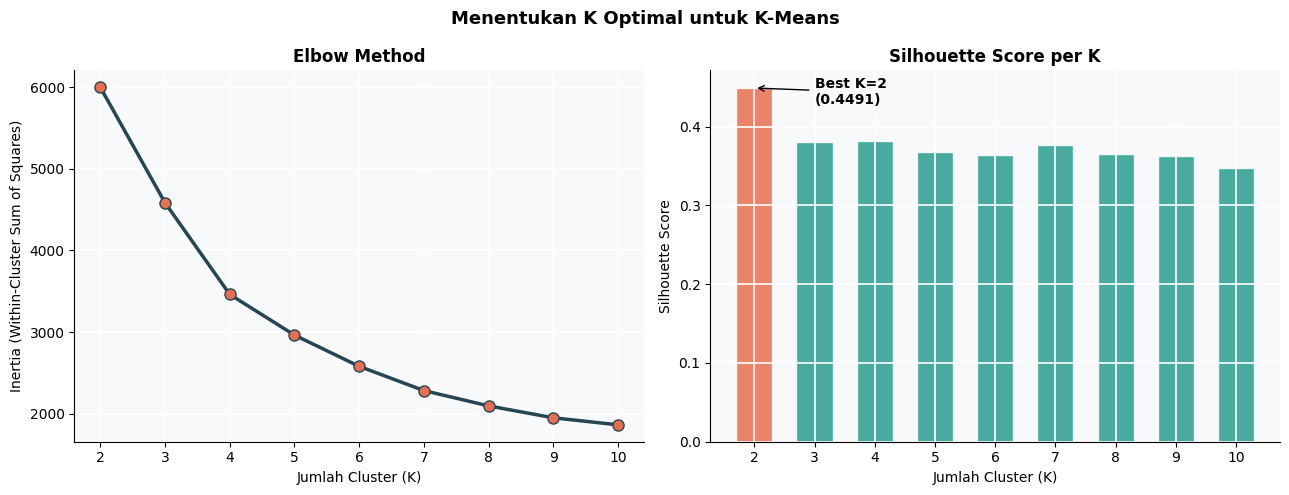


K optimal berdasarkan Silhouette Score: K = 2


In [3]:
k_range     = range(2, 11)
inertias    = []
sil_scores  = []

for k in k_range:
    km  = KMeans(n_clusters=k, random_state=42, n_init=10)
    lbl = km.fit_predict(X_scaled)
    inertias.append(km.inertia_)
    sil_scores.append(silhouette_score(X_scaled, lbl))
    print(f'  K={k}  |  Inertia: {km.inertia_:,.1f}  |  Silhouette: {silhouette_score(X_scaled, lbl):.4f}')

# Visualisasi
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

# Elbow
axes[0].plot(list(k_range), inertias, marker='o', color='#264653',
             linewidth=2.5, markersize=8, markerfacecolor='#E76F51')
axes[0].set_xlabel('Jumlah Cluster (K)')
axes[0].set_ylabel('Inertia (Within-Cluster Sum of Squares)')
axes[0].set_title('Elbow Method', fontweight='bold')
axes[0].set_xticks(list(k_range))

# Silhouette
bar_colors = ['#E76F51' if s == max(sil_scores) else '#2A9D8F' for s in sil_scores]
axes[1].bar(list(k_range), sil_scores, color=bar_colors, alpha=0.85,
            edgecolor='white', width=0.6)
best_k = list(k_range)[sil_scores.index(max(sil_scores))]
axes[1].annotate(f'Best K={best_k}\n({max(sil_scores):.4f})',
                 xy=(best_k, max(sil_scores)),
                 xytext=(best_k + 1, max(sil_scores) - 0.02),
                 arrowprops=dict(arrowstyle='->', color='black'),
                 fontweight='bold', fontsize=10)
axes[1].set_xlabel('Jumlah Cluster (K)')
axes[1].set_ylabel('Silhouette Score')
axes[1].set_title('Silhouette Score per K', fontweight='bold')
axes[1].set_xticks(list(k_range))

plt.suptitle('Menentukan K Optimal untuk K-Means', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('plot_05_optimal_k.png', dpi=150, bbox_inches='tight')
plt.show()
print(f'\nK optimal berdasarkan Silhouette Score: K = {best_k}')

---
## Train K-Means dengan K Optimal

In [4]:
# Gunakan K=4 — kombinasi dari Elbow + Silhouette + makna bisnis
# (4 cluster menghasilkan segmen yang paling dapat diinterpretasikan)
K_FINAL = 4

km_final = KMeans(n_clusters=K_FINAL, random_state=42, n_init=10)
rfm['Cluster'] = km_final.fit_predict(X_scaled)

print(f'K-Means selesai dengan K={K_FINAL}')
print(f'Silhouette Score final: {silhouette_score(X_scaled, rfm["Cluster"]):.4f}')
print('\nJumlah pelanggan per cluster:')
print(rfm['Cluster'].value_counts().sort_index().to_string())

K-Means selesai dengan K=4
Silhouette Score final: 0.3823

Jumlah pelanggan per cluster:
Cluster
0    1182
1     876
2     968
3    1312


---
## Profil Tiap Cluster & Labeling Segmen

In [7]:
# Hitung rata-rata RFM per cluster
cluster_profile = rfm.groupby('Cluster').agg(
    N_Customers = ('Customer ID', 'count'),
    Avg_Recency  = ('Recency',   'mean'),
    Avg_Frequency= ('Frequency', 'mean'),
    Avg_Monetary = ('Monetary',  'mean'),
    Avg_R_Score  = ('R_Score',   'mean'),
    Avg_F_Score  = ('F_Score',   'mean'),
    Avg_M_Score  = ('M_Score',   'mean'),
).round(2)

print('Profil Cluster')
display(cluster_profile)

# Buat total skor RFM
cluster_profile['Avg_RFM_Total'] = (
    cluster_profile['Avg_R_Score'] +
    cluster_profile['Avg_F_Score'] +
    cluster_profile['Avg_M_Score']
)

# Ranking cluster berdasarkan total RFM
ranked = cluster_profile['Avg_RFM_Total'].rank(ascending=False).astype(int)

# Label segmentasi
label_by_rank = {
    1: 'Champions',
    2: 'Loyal Customers',
    3: 'At Risk',
    4: 'Lost Customers'
}

# Mapping cluster ke label
segment_labels = {
    cluster: label_by_rank[rank]
    for cluster, rank in ranked.items()
}

# Tambahkan label ke dataframe
rfm['Segment'] = rfm['Cluster'].map(segment_labels)
cluster_profile['Segment'] = cluster_profile.index.map(segment_labels)

print('\nLabel Segmen per Cluster')
display(
    cluster_profile[
        ['Segment','N_Customers','Avg_Recency',
         'Avg_Frequency','Avg_Monetary','Avg_RFM_Total']
    ]
)

Profil Cluster


,N_Customers,Avg_Recency,Avg_Frequency,Avg_Monetary,Avg_R_Score,Avg_F_Score,Avg_M_Score
Cluster,,,,,,,
0,1182,214.78,1.24,327.71,1.39,1.68,1.74
1,876,108.19,3.49,1617.79,2.24,3.52,3.72
2,968,31.96,1.57,402.85,3.81,2.07,1.96
3,1312,16.65,9.52,5101.17,4.41,4.54,4.42



Label Segmen per Cluster


,Segment,N_Customers,Avg_Recency,Avg_Frequency,Avg_Monetary,Avg_RFM_Total
Cluster,,,,,,
0,Lost Customers,1182,214.78,1.24,327.71,4.81
1,Loyal Customers,876,108.19,3.49,1617.79,9.48
2,At Risk,968,31.96,1.57,402.85,7.84
3,Champions,1312,16.65,9.52,5101.17,13.37


---
## Visualisasi Segmen

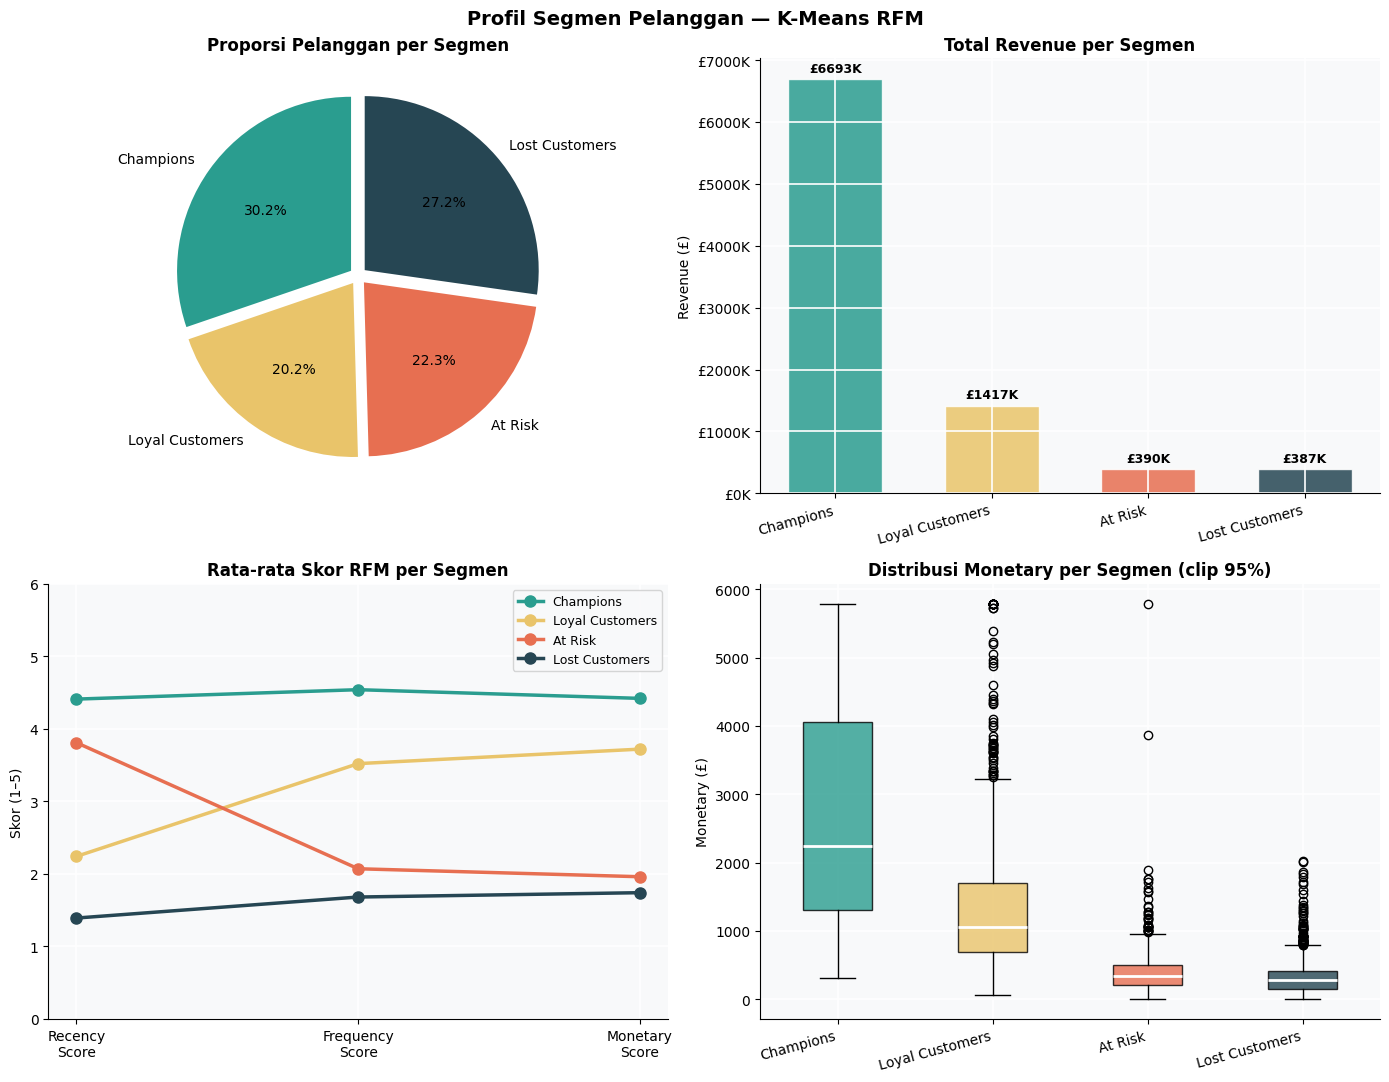

In [10]:
seg_order  = ['Champions', 'Loyal Customers', 'At Risk', 'Lost Customers']
seg_colors = dict(zip(seg_order, CLUSTER_COLORS))
seg_counts = rfm['Segment'].value_counts().reindex(seg_order)
seg_rev    = rfm.groupby('Segment')['Monetary'].sum().reindex(seg_order)

fig, axes = plt.subplots(2, 2, figsize=(14, 11))

# Pie chart jumlah pelanggan
axes[0,0].pie(
    seg_counts.values,
    labels=seg_counts.index,
    colors=[seg_colors[s] for s in seg_order],
    autopct='%1.1f%%',
    explode=[0.05]*4,
    startangle=90,
    textprops={'fontsize': 10}
)
axes[0,0].set_title('Proporsi Pelanggan per Segmen', fontweight='bold')

# Bar revenue per segmen
bars = axes[0,1].bar(
    seg_order, seg_rev.values,
    color=[seg_colors[s] for s in seg_order],
    alpha=0.85, edgecolor='white', width=0.6
)
for bar, val in zip(bars, seg_rev.values):
    axes[0,1].text(bar.get_x() + bar.get_width()/2,
                   bar.get_height() + seg_rev.max()*0.01,
                   f'£{val/1000:.0f}K', ha='center', va='bottom', fontsize=9, fontweight='bold')
axes[0,1].set_title('Total Revenue per Segmen', fontweight='bold')
axes[0,1].set_ylabel('Revenue (£)')
axes[0,1].yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'£{x/1000:.0f}K'))
axes[0,1].set_xticklabels(seg_order, rotation=15, ha='right')

# Snake chart (Radar-like) — rata-rata R/F/M per segmen
metrics = ['Avg_R_Score', 'Avg_F_Score', 'Avg_M_Score']
metric_labels = ['Recency\nScore', 'Frequency\nScore', 'Monetary\nScore']
for seg in seg_order:
    cluster_id = [k for k, v in segment_labels.items() if v == seg][0]
    vals = cluster_profile.loc[cluster_id, metrics].values
    axes[1,0].plot(metric_labels, vals, marker='o', linewidth=2.5,
                   label=seg, color=seg_colors[seg], markersize=8)
axes[1,0].set_ylim(0, 6)
axes[1,0].set_title('Rata-rata Skor RFM per Segmen', fontweight='bold')
axes[1,0].set_ylabel('Skor (1–5)')
axes[1,0].legend(fontsize=9)

# Boxplot Monetary per segmen
rfm_clip = rfm.copy()
rfm_clip['Monetary'] = rfm_clip['Monetary'].clip(0, rfm_clip['Monetary'].quantile(0.95))
data_box = [rfm_clip[rfm_clip['Segment']==s]['Monetary'].values for s in seg_order]
bp = axes[1,1].boxplot(data_box, labels=seg_order, patch_artist=True,
                        notch=False, medianprops=dict(color='white', linewidth=2))
for patch, seg in zip(bp['boxes'], seg_order):
    patch.set_facecolor(seg_colors[seg])
    patch.set_alpha(0.8)
axes[1,1].set_title('Distribusi Monetary per Segmen (clip 95%)', fontweight='bold')
axes[1,1].set_ylabel('Monetary (£)')
axes[1,1].set_xticklabels(seg_order, rotation=15, ha='right')

plt.suptitle('Profil Segmen Pelanggan — K-Means RFM', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('plot_06_segment_profile.png', dpi=150, bbox_inches='tight')
plt.show()

---
## Visualisasi 2D dengan PCA

Explained variance: PC1=71.9%, PC2=19.7%, Total=91.6%


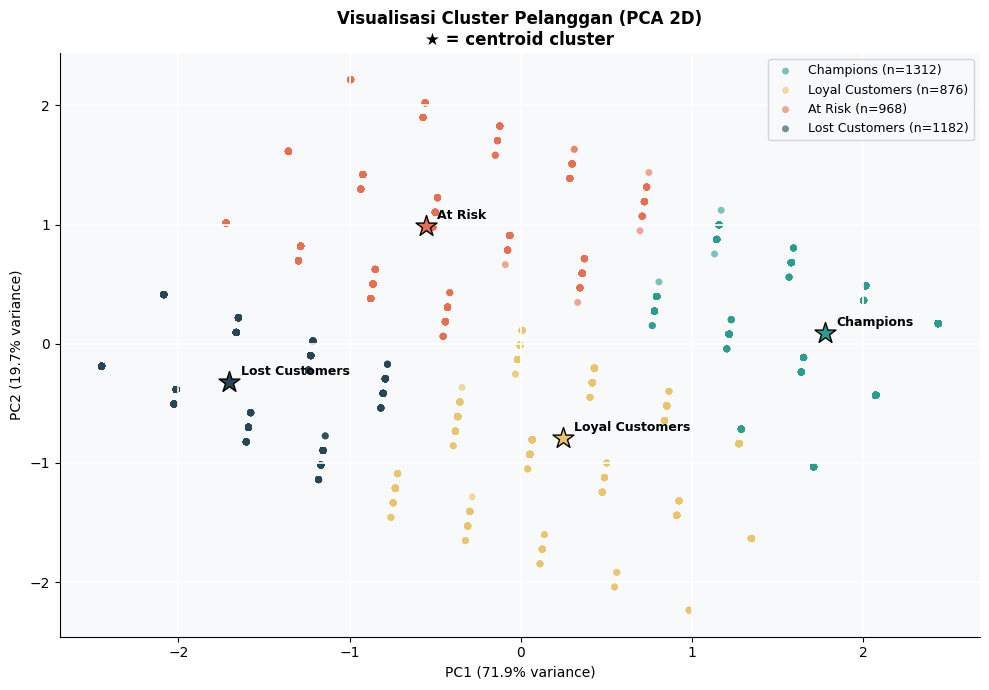

Plot disimpan: plot_07_pca_clusters.png
Data tersimpan: rfm_clustered.csv


In [9]:
pca  = PCA(n_components=2, random_state=42)
X_2d = pca.fit_transform(X_scaled)

rfm['PCA1'] = X_2d[:, 0]
rfm['PCA2'] = X_2d[:, 1]

explained = pca.explained_variance_ratio_ * 100
print(f'Explained variance: PC1={explained[0]:.1f}%, PC2={explained[1]:.1f}%, Total={sum(explained):.1f}%')

fig, ax = plt.subplots(figsize=(10, 7))
for seg in seg_order:
    mask = rfm['Segment'] == seg
    ax.scatter(
        rfm.loc[mask, 'PCA1'],
        rfm.loc[mask, 'PCA2'],
        label=f'{seg} (n={mask.sum()})',
        color=seg_colors[seg],
        alpha=0.6, s=25, edgecolors='none'
    )

# Plot centroids
centroids_2d = pca.transform(km_final.cluster_centers_)
for i, (cx, cy) in enumerate(centroids_2d):
    seg = segment_labels[i]
    ax.scatter(cx, cy, color=seg_colors[seg], s=250, marker='*',
               edgecolors='black', linewidths=1, zorder=5)
    ax.annotate(seg, (cx, cy), textcoords='offset points', xytext=(8, 5),
                fontsize=9, fontweight='bold')

ax.set_xlabel(f'PC1 ({explained[0]:.1f}% variance)')
ax.set_ylabel(f'PC2 ({explained[1]:.1f}% variance)')
ax.set_title('Visualisasi Cluster Pelanggan (PCA 2D)\n★ = centroid cluster', fontweight='bold')
ax.legend(fontsize=9, loc='upper right')
plt.tight_layout()
plt.savefig('plot_07_pca_clusters.png', dpi=150, bbox_inches='tight')
plt.show()
print('Plot disimpan: plot_07_pca_clusters.png')

# Simpan hasil lengkap
rfm.to_csv('rfm_clustered.csv', index=False)
print('Data tersimpan: rfm_clustered.csv')

---
## Ringkasan Clustering

In [11]:
print('   RINGKASAN CUSTOMER SEGMENTATION — K-MEANS RFM')
for seg in seg_order:
    s = rfm[rfm['Segment'] == seg]
    pct = len(s) / len(rfm) * 100
    rev_pct = s['Monetary'].sum() / rfm['Monetary'].sum() * 100
    print(f"""
{seg.upper()} ({len(s):,} pelanggan, {pct:.1f}%)
   Revenue kontribusi : {rev_pct:.1f}% dari total
   Avg Recency        : {s['Recency'].mean():.0f} hari
   Avg Frequency      : {s['Frequency'].mean():.1f} order
   Avg Monetary       : £{s['Monetary'].mean():.2f}""")
print()
print('  NEXT: Notebook 3 — Business Recommendation & Streamlit Dashboard')

   RINGKASAN CUSTOMER SEGMENTATION — K-MEANS RFM

CHAMPIONS (1,312 pelanggan, 30.2%)
   Revenue kontribusi : 75.3% dari total
   Avg Recency        : 17 hari
   Avg Frequency      : 9.5 order
   Avg Monetary       : £5101.17

LOYAL CUSTOMERS (876 pelanggan, 20.2%)
   Revenue kontribusi : 15.9% dari total
   Avg Recency        : 108 hari
   Avg Frequency      : 3.5 order
   Avg Monetary       : £1617.79

AT RISK (968 pelanggan, 22.3%)
   Revenue kontribusi : 4.4% dari total
   Avg Recency        : 32 hari
   Avg Frequency      : 1.6 order
   Avg Monetary       : £402.85

LOST CUSTOMERS (1,182 pelanggan, 27.2%)
   Revenue kontribusi : 4.4% dari total
   Avg Recency        : 215 hari
   Avg Frequency      : 1.2 order
   Avg Monetary       : £327.71

  NEXT: Notebook 3 — Business Recommendation & Streamlit Dashboard
